# Transaction Monitoring Optimization & False Positive Reduction (Python + ML)

## Overview
This project simulates a transaction monitoring system and evaluates how alert quality can be improved by reducing false positives.

It compares a baseline rules-based alert generation approach with a machine learning model (logistic regression) to demonstrate how data-driven methods can enhance detection accuracy and improve investigation efficiency.

The project reflects real-world challenges in financial crime compliance, where high volumes of alerts can create operational inefficiencies and strain investigation resources.

While model performance appears strong due to the use of simulated data, real-world implementation would require larger datasets, robust validation, and ongoing model governance.

---

## Objective
- Simulate baseline alert generation using rules-based logic  
- Identify and quantify false positives  
- Evaluate inefficiencies in traditional transaction monitoring systems  
- Apply a machine learning model to predict true risk  
- Compare rules-based and ML-driven approaches  
- Demonstrate how ML can improve alert precision and reduce investigation workload  

#### Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#### Data

In [2]:
data = {
    "customer_id": ["C001","C002","C003","C004","C005","C006","C007","C008","C009","C010","C011","C012"],
    "country": ["HighRisk","LowRisk","MediumRisk","HighRisk","LowRisk","MediumRisk","HighRisk","LowRisk","MediumRisk","HighRisk","LowRisk","HighRisk"],
    "transaction_amount": [50000, 2000, 15000, 70000, 3000, 12000, 90000, 1000, 18000, 65000, 2500, 40000],
    "txn_count_7d": [15, 2, 8, 20, 1, 7, 25, 1, 9, 18, 2, 14],
    "is_pep": ["Yes","No","No","Yes","No","No","Yes","No","No","No","No","Yes"],
    "is_sanction_hit": ["No","No","No","Yes","No","No","Yes","No","No","No","No","No"],
    "previous_alerts": [5, 0, 2, 6, 0, 1, 7, 0, 2, 4, 0, 3]
}

df = pd.DataFrame(data)
df

,customer_id,country,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,previous_alerts
0,C001,HighRisk,50000,15,Yes,No,5
1,C002,LowRisk,2000,2,No,No,0
2,C003,MediumRisk,15000,8,No,No,2
3,C004,HighRisk,70000,20,Yes,Yes,6
4,C005,LowRisk,3000,1,No,No,0
5,C006,MediumRisk,12000,7,No,No,1
6,C007,HighRisk,90000,25,Yes,Yes,7
7,C008,LowRisk,1000,1,No,No,0
8,C009,MediumRisk,18000,9,No,No,2
9,C010,HighRisk,65000,18,No,No,4


## Baseline Rules-Based Alert System

The baseline system generates alerts using simple thresholds based on transaction amount and frequency.

While effective for broad detection, such systems often generate high volumes of alerts, including false positives.

In [3]:
def generate_alert(row):
    if row["transaction_amount"] > 10000 or row["txn_count_7d"] > 10:
        return 1
    return 0

df["alert_flag"] = df.apply(generate_alert, axis=1)
df

,customer_id,country,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,previous_alerts,alert_flag
0,C001,HighRisk,50000,15,Yes,No,5,1
1,C002,LowRisk,2000,2,No,No,0,0
2,C003,MediumRisk,15000,8,No,No,2,1
3,C004,HighRisk,70000,20,Yes,Yes,6,1
4,C005,LowRisk,3000,1,No,No,0,0
5,C006,MediumRisk,12000,7,No,No,1,1
6,C007,HighRisk,90000,25,Yes,Yes,7,1
7,C008,LowRisk,1000,1,No,No,0,0
8,C009,MediumRisk,18000,9,No,No,2,1
9,C010,HighRisk,65000,18,No,No,4,1


## True Risk Label

A simplified “true risk” label is created to represent genuinely high-risk cases based on stronger AML indicators.

In [4]:
def is_high_risk(row):
    if row["is_sanction_hit"] == "Yes":
        return 1
    if row["is_pep"] == "Yes" and row["transaction_amount"] > 20000:
        return 1
    if row["country"] == "HighRisk" and row["txn_count_7d"] > 10:
        return 1
    return 0

df["true_risk"] = df.apply(is_high_risk, axis=1)
df

,customer_id,country,transaction_amount,txn_count_7d,is_pep,is_sanction_hit,previous_alerts,alert_flag,true_risk
0,C001,HighRisk,50000,15,Yes,No,5,1,1
1,C002,LowRisk,2000,2,No,No,0,0,0
2,C003,MediumRisk,15000,8,No,No,2,1,0
3,C004,HighRisk,70000,20,Yes,Yes,6,1,1
4,C005,LowRisk,3000,1,No,No,0,0,0
5,C006,MediumRisk,12000,7,No,No,1,1,0
6,C007,HighRisk,90000,25,Yes,Yes,7,1,1
7,C008,LowRisk,1000,1,No,No,0,0,0
8,C009,MediumRisk,18000,9,No,No,2,1,0
9,C010,HighRisk,65000,18,No,No,4,1,1


In [5]:
df["false_positive"] = ((df["alert_flag"] == 1) & (df["true_risk"] == 0)).astype(int)

total_alerts = df["alert_flag"].sum()
false_positives = df["false_positive"].sum()

print("Baseline Alerts:", total_alerts)
print("False Positives:", false_positives)

Baseline Alerts: 8
False Positives: 3


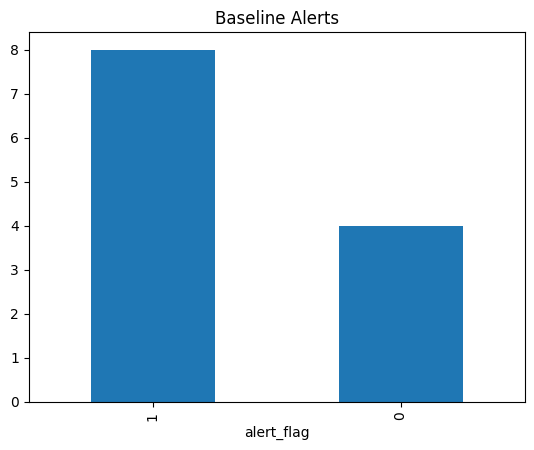

In [6]:
df["alert_flag"].value_counts().plot(kind="bar")
plt.title("Baseline Alerts")
plt.show()

## Machine Learning Approach

A logistic regression model is applied to predict true risk based on customer and transaction features.

This allows comparison between rules-based and data-driven approaches.

In [7]:
df_ml = df.copy()

df_ml["country"] = df_ml["country"].map({"LowRisk":0,"MediumRisk":1,"HighRisk":2})
df_ml["is_pep"] = df_ml["is_pep"].map({"No":0,"Yes":1})
df_ml["is_sanction_hit"] = df_ml["is_sanction_hit"].map({"No":0,"Yes":1})

X = df_ml[["country","transaction_amount","txn_count_7d","is_pep","is_sanction_hit","previous_alerts"]]
y = df_ml["true_risk"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [10]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2 0]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [11]:
df_ml["ml_predicted_risk"] = model.predict(X)

In [12]:
df_ml["rules_fp"] = ((df["alert_flag"] == 1) & (df["true_risk"] == 0)).astype(int)
df_ml["ml_fp"] = ((df_ml["ml_predicted_risk"] == 1) & (df_ml["true_risk"] == 0)).astype(int)

comparison = pd.Series({
    "Rules-Based": df_ml["rules_fp"].sum(),
    "ML-Based": df_ml["ml_fp"].sum()
})

comparison

Rules-Based    3
ML-Based       0
dtype: int64

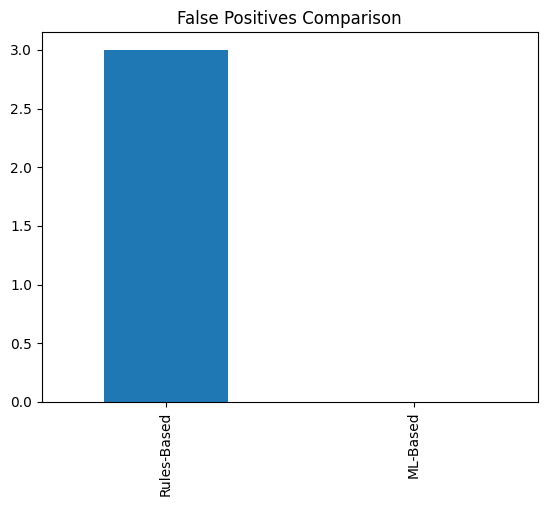

In [13]:
comparison.plot(kind="bar")
plt.title("False Positives Comparison")
plt.show()

## Key Result

The machine learning model demonstrates improved precision in identifying true high-risk cases, reducing false positives compared to the rules-based approach.

This highlights the potential of ML to enhance alert quality and reduce investigation workload in transaction monitoring systems.

## Results Comparison

The ML model demonstrates a more targeted approach compared to rules-based logic, reducing unnecessary alerts and improving detection precision.

Notably, the reduction in false positives highlights the potential for machine learning to optimise investigation workloads, allowing resources to be focused on genuinely high-risk cases.

This reflects real-world challenges in transaction monitoring, where balancing detection effectiveness and operational efficiency is critical.

In practice, model performance would depend on data quality, feature engineering, and continuous monitoring to avoid model drift.

The ML model demonstrates improved precision in identifying true high-risk cases, reducing false positives compared to the rules-based approach.

## Model Limitations

This project uses a small simulated dataset. In real-world applications, models require large datasets, validation, and governance before deployment.

## Feature Importance

This chart shows which factors contribute most to predicting high-risk customers.

It helps explain the model’s decision-making and aligns with real-world requirements for model interpretability in financial crime compliance.

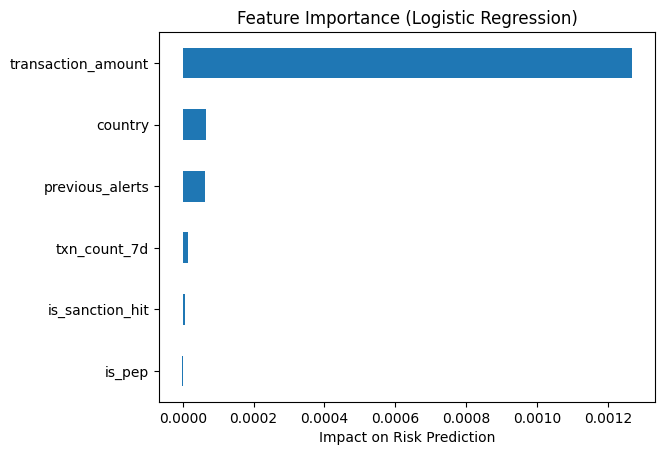

In [15]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind="barh")

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Impact on Risk Prediction")
plt.show()